# PART 1 — Project Introduction

# # Customer Default Risk Prediction Using Machine Learning

## Project Overview

This project focuses on predicting whether a customer is likely to
default on a loan using machine learning classification algorithms.

The dataset contains 10,000 customer records with demographic,
financial, credit-related, categorical, and date-based information.

The project covers:

- Exploratory Data Analysis (EDA)
- Data Cleaning
- Missing Value Treatment
- Outlier Analysis
- Categorical Data Encoding
- Feature Engineering
- Feature Scaling
- Machine Learning Model Building
- Model Evaluation
- Cross-Validation
- Hyperparameter Tuning
- Model Comparison
- Feature Importance

## Objective

The main objective is to develop a classification model that can
predict the customer's default risk accurately and reliably.

# PART 2 — Import Libraries

In [161]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")


# PART 3 — Load Dataset

In [162]:
df = pd.read_csv("synthetic_dataset_10000x20.csv")

df.head()

,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,education,marital_status,region,recent_default,has_credit_card,signup_date,signup_dayofweek,debt_to_income,sin_age,target_default_risk
0,CUST006253,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,...,HS,Single,West,1,1,2020-07-05,6,0.404,0.141120,1
1,CUST004685,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,...,Bachelors,Married,East,0,0,2018-10-03,2,0.066,0.808496,1
2,CUST001732,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,...,Bachelors,Single,East,0,1,2018-05-30,2,0.325,0.494113,0
3,CUST004743,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,...,HS,Married,South,0,1,2018-04-22,6,0.719,-0.982453,0
4,CUST004522,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,...,Masters,Single,West,0,0,2019-12-03,1,0.324,0.898708,1


# PART 4 — Understand the Dataset

In [163]:
print("Dataset Shape:",df.shape)

Dataset Shape: (10000, 21)


In [164]:
print("Number of rows:",df.shape[0])
print("Number of Columns:",df.shape[1])

Number of rows: 10000
Number of Columns: 21


In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          10000 non-null  object 
 1   age                  10000 non-null  int64  
 2   income               9682 non-null   float64
 3   savings              9689 non-null   float64
 4   monthly_expenses     9675 non-null   float64
 5   num_dependents       10000 non-null  int64  
 6   credit_score         9674 non-null   float64
 7   loan_amount          10000 non-null  float64
 8   loan_term_months     10000 non-null  int64  
 9   employment_years     10000 non-null  float64
 10  home_ownership       10000 non-null  object 
 11  education            10000 non-null  object 
 12  marital_status       10000 non-null  object 
 13  region               10000 non-null  object 
 14  recent_default       10000 non-null  int64  
 15  has_credit_card      10000 non-null  

In [166]:
df.describe()

,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,recent_default,has_credit_card,signup_dayofweek,debt_to_income,sin_age,target_default_risk
count,10000.000000,9682.000000,9689.000000,9675.000000,10000.000000,9674.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,45.861600,59712.871411,5039.922489,2082.209612,1.214200,650.155438,16214.796900,45.642000,5.39701,0.047000,0.694800,3.011900,0.358156,-0.100387,0.513200
std,16.457987,39865.231489,5041.793583,1385.991787,1.108982,69.918297,16081.646814,15.475134,3.41370,0.211649,0.460515,2.003986,0.302606,0.667428,0.499851
min,18.000000,20001.000000,0.000000,200.000000,0.000000,363.077116,1000.000000,12.000000,0.00000,0.000000,0.000000,0.000000,0.004000,-0.999923,0.000000
25%,32.000000,31300.500000,1476.000000,1471.000000,0.000000,602.189895,8508.500000,36.000000,2.70000,0.000000,0.000000,1.000000,0.132000,-0.756802,0.000000
50%,46.000000,47301.500000,3499.000000,2007.000000,1.000000,649.808322,15174.500000,48.000000,5.10000,0.000000,1.000000,3.000000,0.275000,-0.157746,1.000000
75%,60.000000,75164.250000,6986.000000,2557.000000,2.000000,697.537432,21843.750000,60.000000,7.70000,0.000000,1.000000,5.000000,0.508000,0.515501,1.000000
max,74.000000,402769.000000,44644.000000,28664.000000,7.000000,850.000000,441190.000000,72.000000,21.50000,1.000000,1.000000,6.000000,2.031000,0.973848,1.000000


| Code         | Purpose                     |
| ------------ | --------------------------- |
| `shape`      | rows and columns            |
| `info()`     | data types + missing values |
| `describe()` | statistical summary         |
| `head()`     | sample records              |


# PART 5 — Data Quality Check

## Missing values

In [167]:
missing=pd.DataFrame({
    "Missing_Count":df.isnull().sum(),
    "Missing_Percentage":(
        df.isnull().sum()/len(df)*100
    )
})

missing.sort_values(
    by="Missing_Count",
    ascending=False
)

,Missing_Count,Missing_Percentage
credit_score,326,3.26
monthly_expenses,325,3.25
income,318,3.18
savings,311,3.11
customer_id,0,0.00
region,0,0.00
sin_age,0,0.00
debt_to_income,0,0.00
signup_dayofweek,0,0.00
signup_date,0,0.00


## Duplicate records

In [168]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


## Unique values


In [169]:
for column in df.select_dtypes(include="object").columns:
    print("\n",column)
    print(df[column].value_counts(dropna=False))


 customer_id
customer_id
CUST006253    1
CUST001238    1
CUST001308    1
CUST009430    1
CUST000999    1
             ..
CUST002729    1
CUST009598    1
CUST004986    1
CUST006847    1
CUST007271    1
Name: count, Length: 10000, dtype: int64

 home_ownership
home_ownership
RENT        4524
OWN         2526
MORTGAGE    2498
OTHER        452
Name: count, dtype: int64

 education
education
Bachelors    4443
HS           2546
Masters      1962
Other         500
PhD           462
Bachlors       87
Name: count, dtype: int64

 marital_status
marital_status
Single      4486
Married     4002
Divorced    1000
Widowed      512
Name: count, dtype: int64

 region
region
East     2553
South    2523
North    2479
West     2445
Name: count, dtype: int64

 signup_date
signup_date
2018-06-22    14
2021-04-14    13
2021-01-27    13
2021-11-14    13
2022-05-07    12
              ..
2023-04-16     1
2022-05-31     1
2020-03-22     1
2022-07-31     1
2018-11-04     1
Name: count, Length: 1982, dtype: int6

## PART 6 — Target Analysis

In [170]:
target_counts=df["target_default_risk"].value_counts()
print(target_counts)

target_default_risk
1    5132
0    4868
Name: count, dtype: int64


In [171]:
target_percentage=(
    df["target_default_risk"]
    .value_counts(normalize=True)*100
)
print(target_percentage)

target_default_risk
1    51.32
0    48.68
Name: proportion, dtype: float64


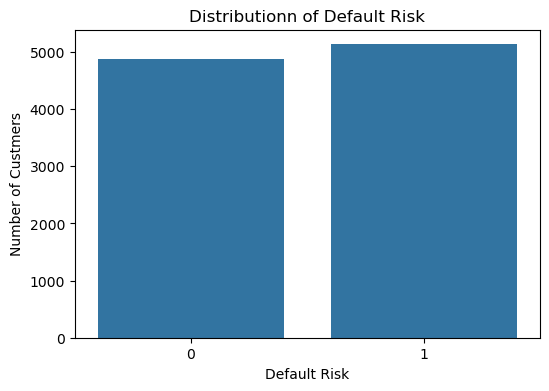

In [172]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="target_default_risk"
)

plt.title("Distributionn of Default Risk")
plt.xlabel("Default Risk")
plt.ylabel("Number of Custmers")

plt.show()

## PART 7 — EDA

- 7.1 Numerical Features

In [173]:
numeric_features=df.select_dtypes(
    include=["int64","float64"]).columns.tolist()
print(numeric_features)

['age', 'income', 'savings', 'monthly_expenses', 'num_dependents', 'credit_score', 'loan_amount', 'loan_term_months', 'employment_years', 'recent_default', 'has_credit_card', 'signup_dayofweek', 'debt_to_income', 'sin_age', 'target_default_risk']


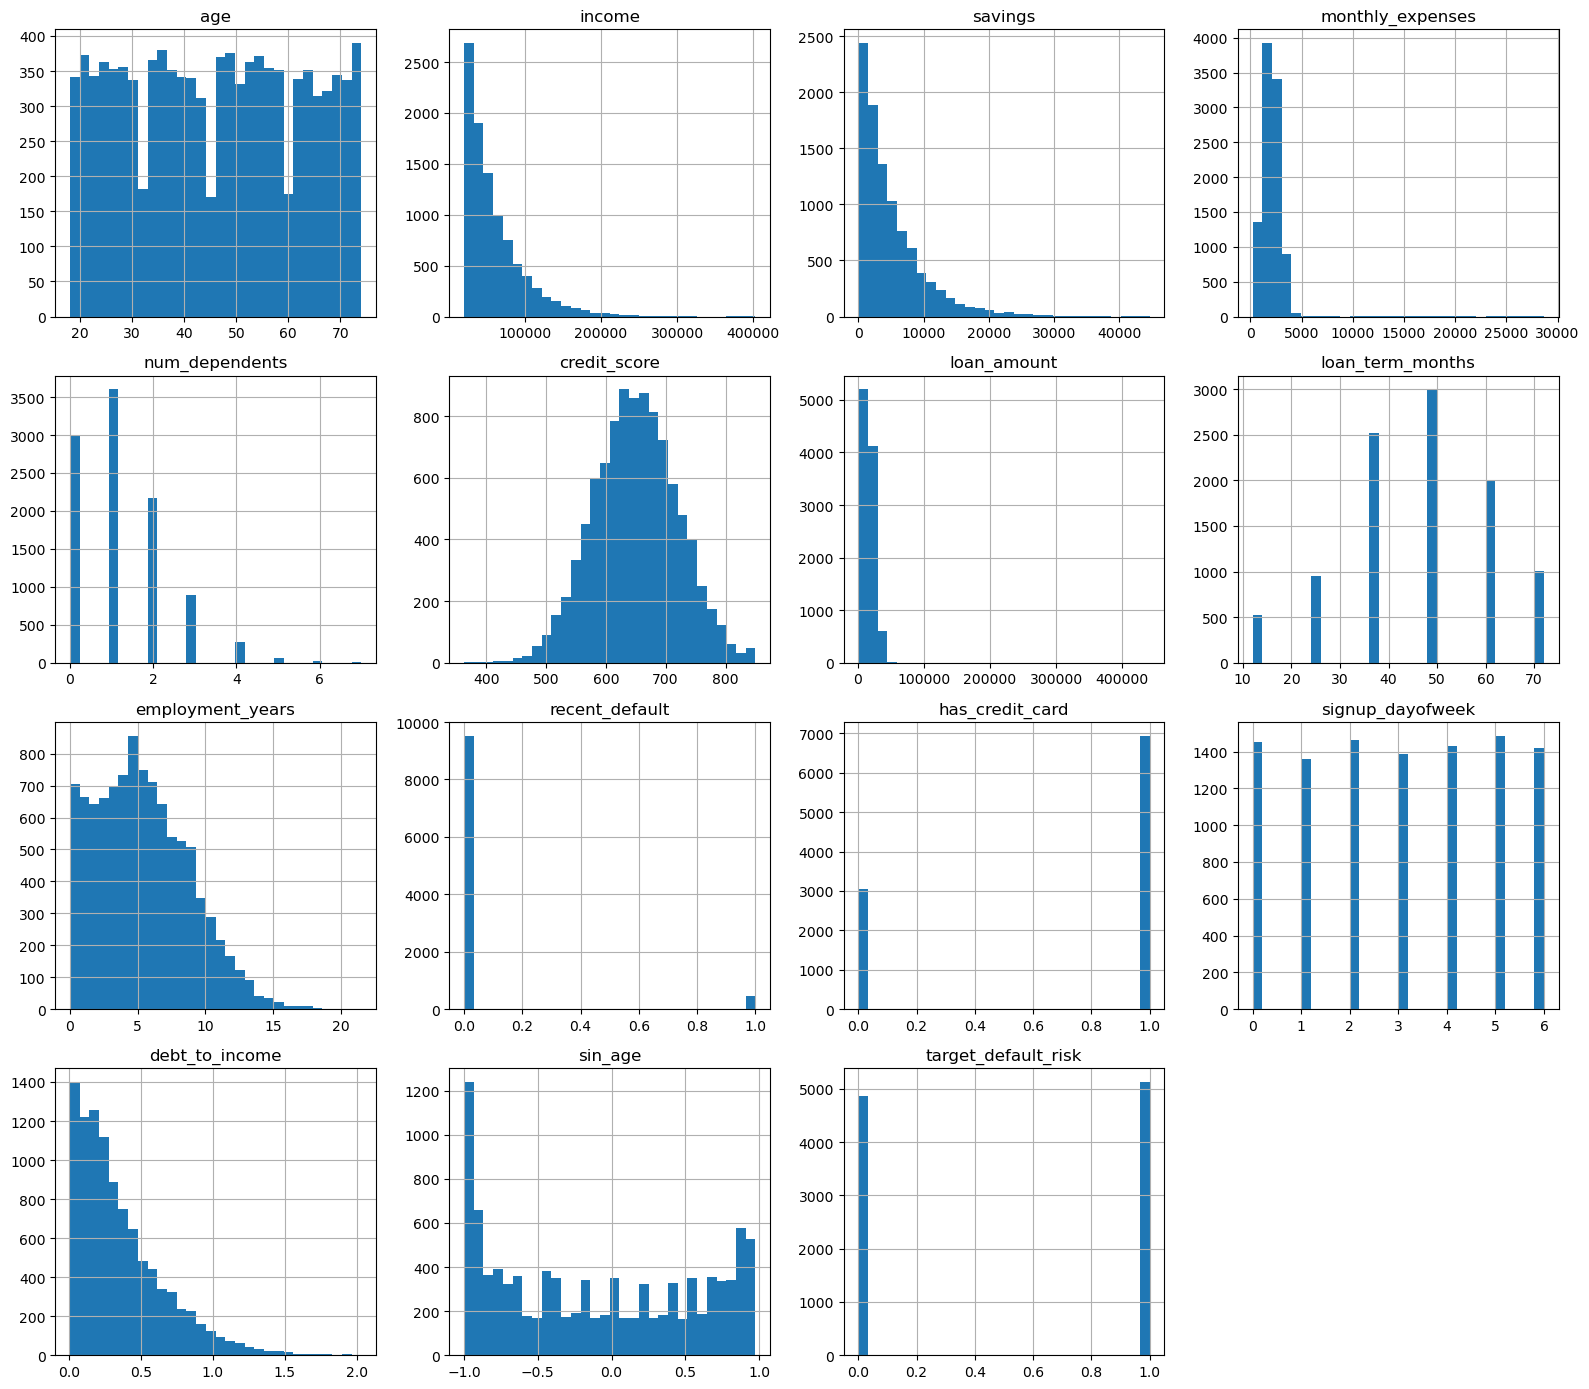

In [174]:
df[numeric_features].hist(
    figsize=(16,14),
    bins=30)
plt.tight_layout()
plt.show()

## PART 8 — Outlier Analysis

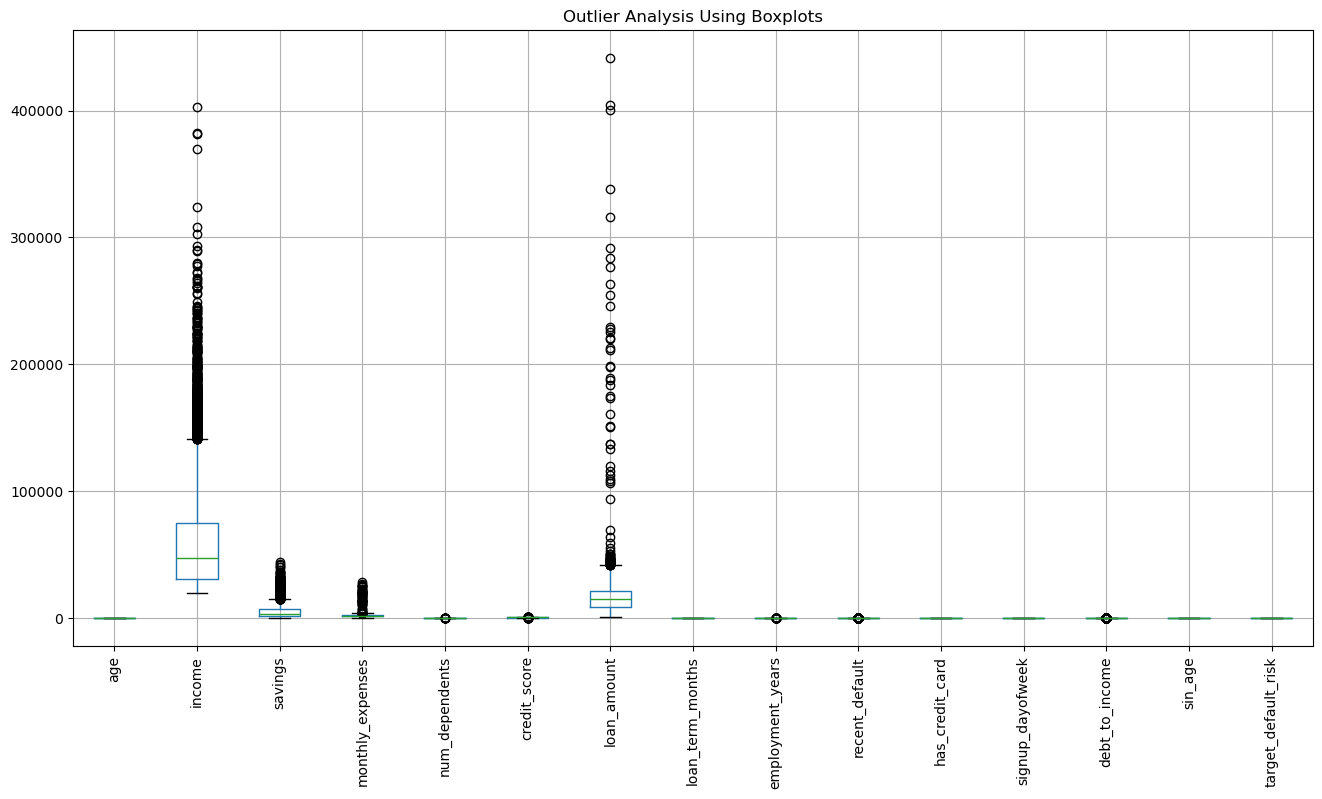

In [175]:
plt.figure(figsize=(16,8))
df[numeric_features].boxplot()
plt.xticks(rotation=90)
plt.title("Outlier Analysis Using Boxplots")
plt.show()

#### Then calculate IQR:

In [176]:
outlier_summary = []

for column in numeric_features:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = (
        (df[column] < lower) |
        (df[column] > upper)
    ).sum()

    outlier_summary.append({
        "Feature": column,
        "Outlier_Count": count
    })

outlier_summary = pd.DataFrame(
    outlier_summary
)

outlier_summary.sort_values(
    by="Outlier_Count",
    ascending=False
)

,Feature,Outlier_Count
1,income,479
2,savings,472
9,recent_default,470
12,debt_to_income,318
6,loan_amount,89
3,monthly_expenses,70
5,credit_score,62
8,employment_years,51
4,num_dependents,24
0,age,0


## PART 9 — Categorical EDA

In [177]:
categorical_features=df.select_dtypes(
    include="object"
).columns.tolist()
print(categorical_features)

['customer_id', 'home_ownership', 'education', 'marital_status', 'region', 'signup_date']


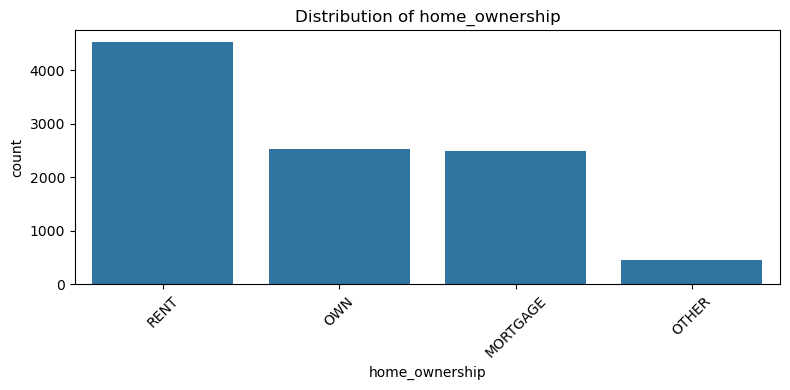

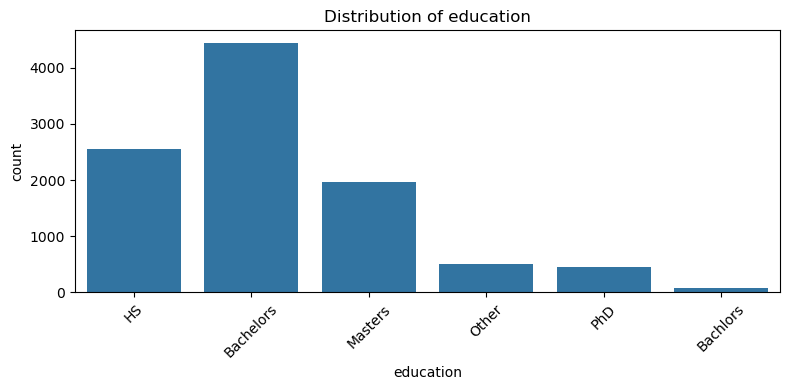

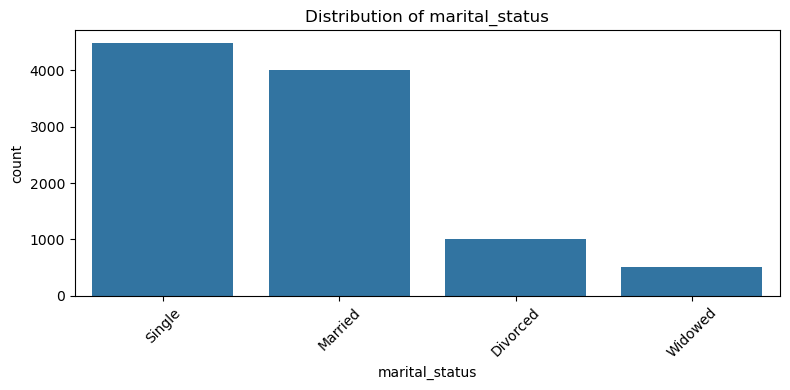

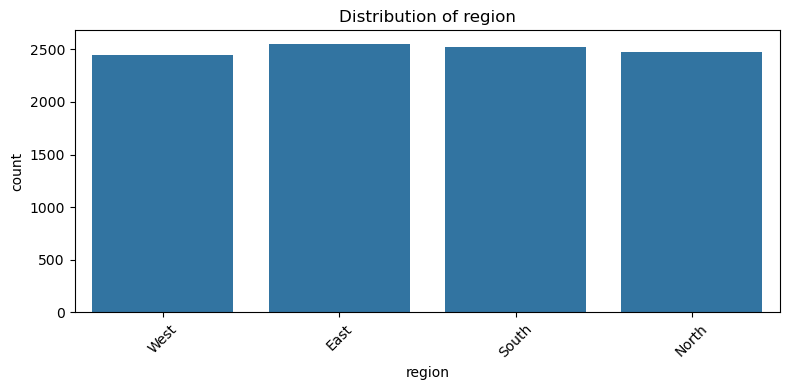

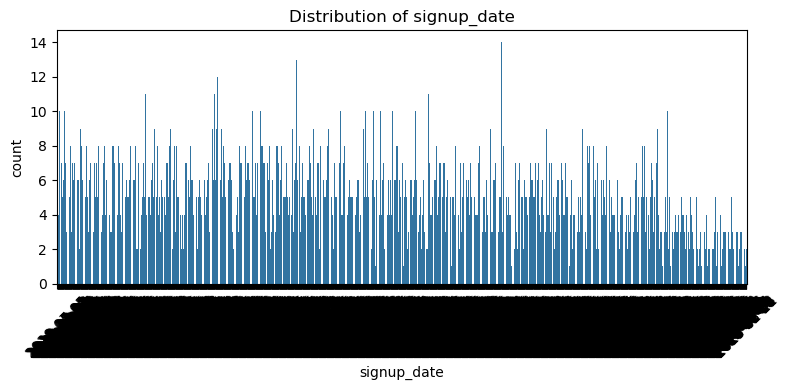

In [178]:
for column in categorical_features:
    if column !="customer_id":
        plt.figure(figsize=(8,4))

        sns.countplot(
             data=df,
             x=column
        )

        plt.title(
            f"Distribution of {column}"
        )

        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

## PART 10 — Correlation Analysis

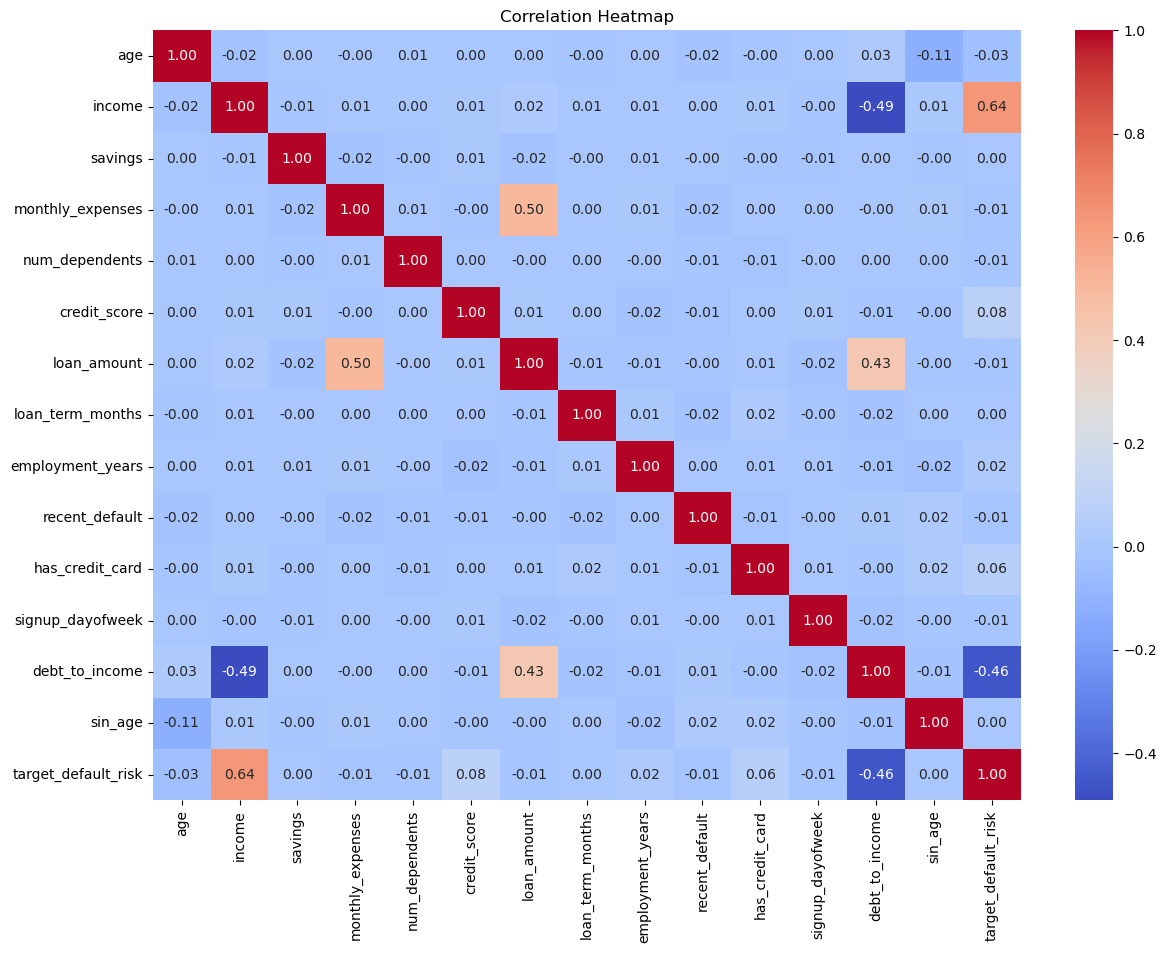

In [179]:
correlation=df.corr(
    numeric_only=True
)

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## PART 11 — Date Feature Engineering

In [180]:
df["signup_date"]=pd.to_datetime(
    df["signup_date"],
    errors="coerce"
    
)


### Create useful features:

In [181]:
df["signup_year"]=(
    df["signup_date"].dt.month
)
df["signup_month"]=(
    df["signup_date"].dt.month
)
df["signup_day"]=(
    df["signup_date"].dt.day
)

In [182]:
#remove original date:
df.drop(
    columns=["signup_date"],
    inplace=True
)

## PART 12 — Feature Engineering

We'll create only a couple of understandable features.

In [183]:
df["income_per_dependet"]=(
    df["income"]/
    (df["num_dependents"]+1)
)

Loan-to-income ration


In [184]:
df["loan_to_income"]=(
    df["loan_amount"]/
    (df["income"]+1)
)

I created ratio-based features to capture the relationship between the customer's financial capacity and loan burden.

## PART 13 — Clean Category Typos

In [185]:
print(
    df["education"].value_counts(
        dropna=False
    )
)

education
Bachelors    4443
HS           2546
Masters      1962
Other         500
PhD           462
Bachlors       87
Name: count, dtype: int64


In [186]:
# if your dataset contain a typo like
#Bachlors
df["education"]=df["education"].replace(
    {
        "Bachlors":"Bachelor"
    }
)
#Don't blindly use this replacement if that value isn't actually present.
#Same process applies to any other actual category inconsistency you find.


## PART 14 — Remove Customer ID

In [187]:
df.drop(
    columns=["customer_id"],
    inplace=True,errors='ignore'
)
#The ID doesn't tell us whether somebody will default.


In [188]:
df.columns

Index(['age', 'income', 'savings', 'monthly_expenses', 'num_dependents',
       'credit_score', 'loan_amount', 'loan_term_months', 'employment_years',
       'home_ownership', 'education', 'marital_status', 'region',
       'recent_default', 'has_credit_card', 'signup_dayofweek',
       'debt_to_income', 'sin_age', 'target_default_risk', 'signup_year',
       'signup_month', 'signup_day', 'income_per_dependet', 'loan_to_income'],
      dtype='object')

## PART 15 — Separate Features and Target

In [189]:
X=df.drop(columns=["target_default_risk"])
y=df["target_default_risk"]

In [190]:
X

,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,home_ownership,...,recent_default,has_credit_card,signup_dayofweek,debt_to_income,sin_age,signup_year,signup_month,signup_day,income_per_dependet,loan_to_income
0,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,RENT,...,1,1,6,0.404,0.141120,7,7,5,22245.666667,0.404043
1,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,RENT,...,0,0,2,0.066,0.808496,10,10,3,35370.000000,0.066171
2,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,OWN,...,0,1,2,0.325,0.494113,5,5,30,38890.000000,0.324831
3,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,OWN,...,0,1,6,0.719,-0.982453,4,4,22,14524.500000,0.718795
4,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,MORTGAGE,...,0,0,1,0.324,0.898708,12,12,3,20021.000000,0.323621
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,54,44507.0,5975.0,2520.0,1,699.633352,31089.0,48,5.3,RENT,...,0,1,3,0.699,-0.772764,2,2,27,22253.500000,0.698504
9996,50,20651.0,10203.0,1020.0,3,680.774066,8977.0,60,9.6,RENT,...,0,0,3,0.435,-0.958924,8,8,23,5162.750000,0.434679
9997,43,33827.0,3848.0,2562.0,1,655.562748,24319.0,60,4.3,OTHER,...,0,0,4,0.719,-0.916166,1,1,18,16913.500000,0.718902
9998,44,38273.0,18880.0,1060.0,2,653.277645,1000.0,24,11.4,MORTGAGE,...,0,1,6,0.026,-0.951602,8,8,4,12757.666667,0.026127


In [191]:
y

0       1
1       1
2       0
3       0
4       1
       ..
9995    1
9996    0
9997    0
9998    0
9999    1
Name: target_default_risk, Length: 10000, dtype: int64

## PART 16 — Train-Test Split

In [192]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
# stratify=y It maintains approximately the same target-class proportions in train and test sets.

## PART 17 — Preprocessing Pipeline

In [193]:
numeric_features=X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features=X_train.select_dtypes(include=["object"]).columns.tolist()
print("numeric_features:\n",numeric_features)
print("categorical_features:\n",categorical_features)

numeric_features:
 ['age', 'income', 'savings', 'monthly_expenses', 'num_dependents', 'credit_score', 'loan_amount', 'loan_term_months', 'employment_years', 'recent_default', 'has_credit_card', 'signup_dayofweek', 'debt_to_income', 'sin_age', 'income_per_dependet', 'loan_to_income']
categorical_features:
 ['home_ownership', 'education', 'marital_status', 'region']


Numerical preprocessing

In [194]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [195]:
categorical_pipeline=Pipeline(
    steps=[
        (
           "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

### Combine them

In [196]:
preprocessor=ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

## PART 18 — Build Models

In [197]:
logistic_model=Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

## 18.2 Decision Tree

In [198]:
decision_tree_model=Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

## 18.3 SVM

In [199]:
svm_model=Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            SVC()
        )
    ]

)

##  18.4 Random Forest

In [200]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

##  18.5 XGBoost

In [201]:
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=100,
                max_depth=5,
                learning_rate=0.1,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

## PART 19 — Train All Models

Instead of repeating five blocks, we can make a dictionary.

In [224]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "SVM": svm_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model
}

Train:

In [225]:
for name, model in models.items():

    print(f"Training {name}...")

    model.fit(
        X_train,
        y_train
    )

print("Training completed.")

Training Logistic Regression...
Training Decision Tree...
Training SVM...
Training Random Forest...
Training XGBoost...
Training completed.


## PART 20 — Evaluate All Models

In [226]:
def evaluate_model(
    name,
    model,
    X_test,
    y_test
):

    y_pred = model.predict(
        X_test
    )

    return {
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        )
    }

In [227]:
results = []

for name, model in models.items():

    result = evaluate_model(
        name,
        model,
        X_test,
        y_test
    )

    results.append(result)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9365,0.961026,0.913255,0.936532
1,Decision Tree,0.9210,0.920543,0.925926,0.923226
2,SVM,0.9380,0.960204,0.917154,0.938185
3,Random Forest,0.9395,0.953862,0.926901,0.940188
4,XGBoost,0.9590,0.965483,0.954191,0.959804


## PART 21 — Confusion Matrix

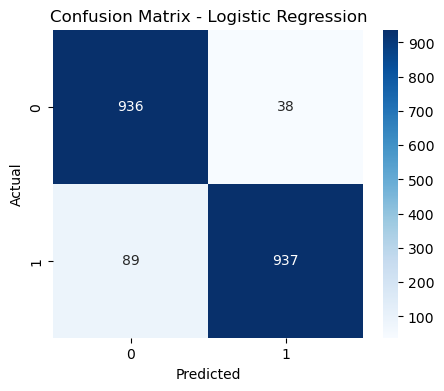

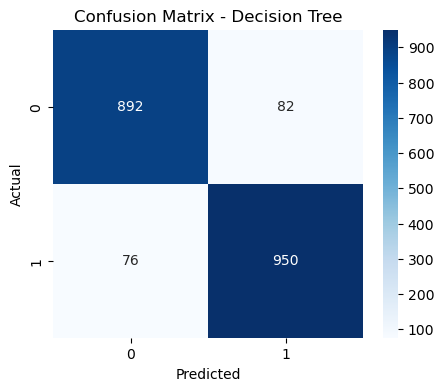

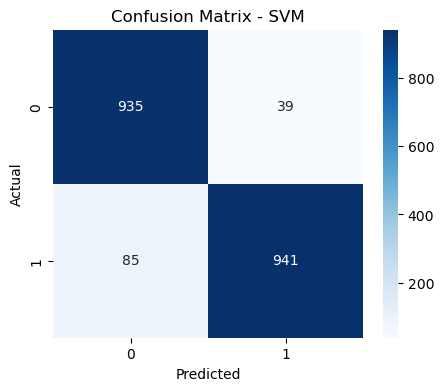

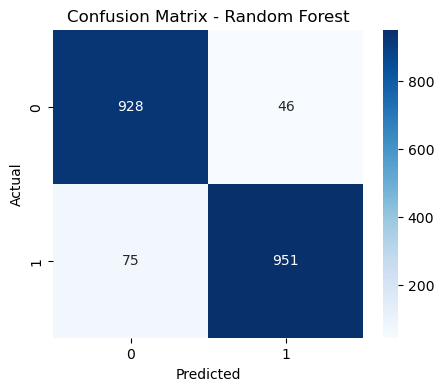

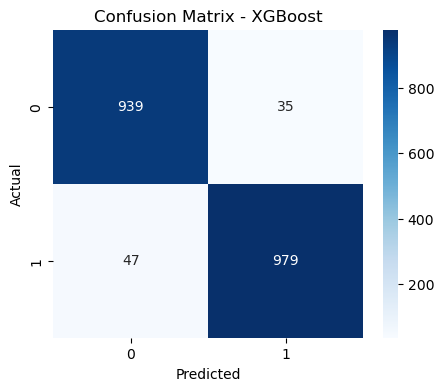

In [206]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(
        f"Confusion Matrix - {name}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

## PART 22 — Classification Report

In [207]:
xgb_predictions = xgb_model.predict(
    X_test
)

print(
    classification_report(
        y_test,
        xgb_predictions
    )
)

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       974
           1       0.97      0.95      0.96      1026

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



## PART 23 — Cross-Validation

In [208]:
rf_cv_scores = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross-validation scores:")
print(rf_cv_scores)

print(
    "Mean CV F1 Score:",
    rf_cv_scores.mean()
)

Cross-validation scores:
[0.92517007 0.92385148 0.92565056 0.92393321 0.93776956]
Mean CV F1 Score: 0.9272749753503182


## PART 24 — Hyperparameter Tuning

In [209]:
rf_params = {
    "model__n_estimators": [
        100,
        200
    ],

    "model__max_depth": [
        None,
        10,
        20
    ],

    "model__min_samples_split": [
        2,
        5
    ]
}

### GridSearch:

In [210]:
rf_grid = GridSearchCV(
    estimator=random_forest_model,
    param_grid=rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

Train:

In [211]:
rf_grid.fit(
    X_train,
    y_train
)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numeric', ...), ('categorical', ...)]"


Best parameters:

In [212]:
print(
    "Best Parameters:"
)

print(
    rf_grid.best_params_
)

Best Parameters:
{'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}


Best Cv score

In [213]:
print(
    "Best CV F1:",
    rf_grid.best_score_
)

Best CV F1: 0.9280392055566825


##  PART 25 — Tuned Random Forest Test Performance

In [214]:
rf_tuned_predictions = rf_grid.predict(
    X_test
)

In [215]:
rf_tuned_accuracy = accuracy_score(
    y_test,
    rf_tuned_predictions
)

rf_tuned_precision = precision_score(
    y_test,
    rf_tuned_predictions,
    zero_division=0
)

rf_tuned_recall = recall_score(
    y_test,
    rf_tuned_predictions,
    zero_division=0
)

rf_tuned_f1 = f1_score(
    y_test,
    rf_tuned_predictions,
    zero_division=0
)

print("Tuned Random Forest")
print("-------------------")
print("Accuracy :", rf_tuned_accuracy)
print("Precision:", rf_tuned_precision)
print("Recall   :", rf_tuned_recall)
print("F1 Score :", rf_tuned_f1)

Tuned Random Forest
-------------------
Accuracy : 0.94
Precision: 0.9539078156312625
Recall   : 0.9278752436647173
F1 Score : 0.9407114624505929


##  PART 26 — Feature Importance

First get the trained preprocessing

In [216]:
best_rf = rf_grid.best_estimator_

preprocessor_fitted = (
    best_rf.named_steps["preprocessor"]
)

rf_model_fitted = (
    best_rf.named_steps["model"]
)

Get feature names:

In [217]:
feature_names=(
    preprocessor_fitted
    .get_feature_names_out()
)

Get importance:

In [218]:
importance = (
    rf_model_fitted
    .feature_importances_
)

Create table:

In [219]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

Shop top 15:

In [220]:
feature_importance_df.head(15)

,Feature,Importance
1,numeric__income,0.453834
14,numeric__income_per_dependet,0.126442
12,numeric__debt_to_income,0.099959
15,numeric__loan_to_income,0.080962
6,numeric__loan_amount,0.049402
5,numeric__credit_score,0.040427
4,numeric__num_dependents,0.023645
2,numeric__savings,0.016358
3,numeric__monthly_expenses,0.016031
8,numeric__employment_years,0.015182


Plot:

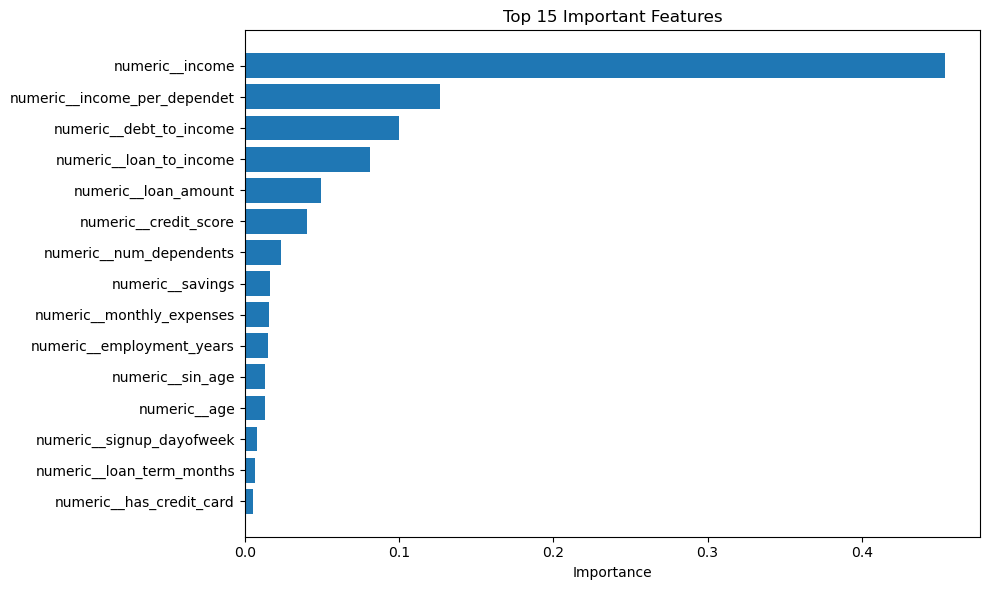

In [221]:
top_features = (
    feature_importance_df
    .head(15)
    .sort_values(
        by="Importance"
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 15 Important Features"
)

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

##  PART 27 — Final Model Comparison

Add tuned Random Forest:

In [222]:
tuned_result = {
    "Model": "Tuned Random Forest",
    "Accuracy": rf_tuned_accuracy,
    "Precision": rf_tuned_precision,
    "Recall": rf_tuned_recall,
    "F1 Score": rf_tuned_f1
}

In [228]:
final_results = pd.concat(
    [
        results_df,
        pd.DataFrame([tuned_result])
    ],
    ignore_index=True
)

final_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9365,0.961026,0.913255,0.936532
1,Decision Tree,0.9210,0.920543,0.925926,0.923226
2,SVM,0.9380,0.960204,0.917154,0.938185
3,Random Forest,0.9395,0.953862,0.926901,0.940188
4,XGBoost,0.9590,0.965483,0.954191,0.959804
5,Tuned Random Forest,0.9400,0.953908,0.927875,0.940711


Sort:

In [229]:
final_results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
4,XGBoost,0.9590,0.965483,0.954191,0.959804
5,Tuned Random Forest,0.9400,0.953908,0.927875,0.940711
3,Random Forest,0.9395,0.953862,0.926901,0.940188
2,SVM,0.9380,0.960204,0.917154,0.938185
0,Logistic Regression,0.9365,0.961026,0.913255,0.936532
1,Decision Tree,0.9210,0.920543,0.925926,0.923226


## PART 28 — Final Visualization

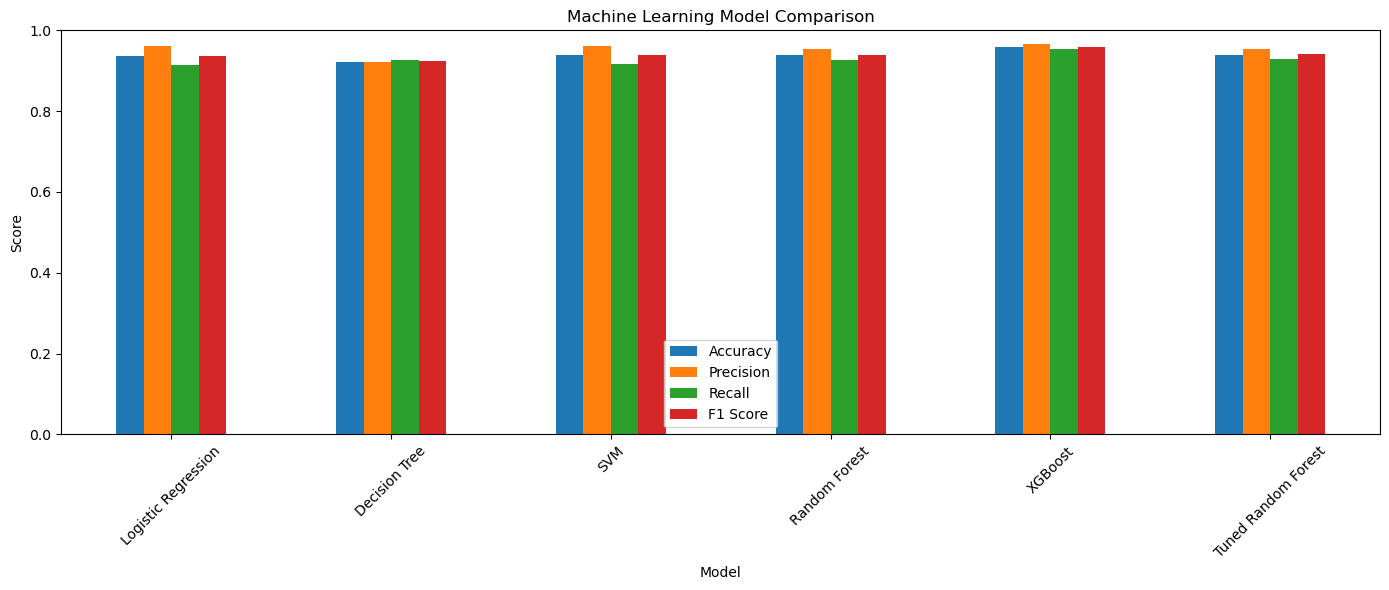

In [230]:
final_results.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title(
    "Machine Learning Model Comparison"
)

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

## PART 29 — Final Prediction Example

Take one test customer

In [231]:
sample_customer = X_test.iloc[[0]]

prediction = rf_grid.predict(
    sample_customer
)

print(
    "Predicted Default Risk:",
    prediction[0]
)

Predicted Default Risk: 0


Then:

In [232]:
if prediction[0] == 1:
    print("Prediction: Customer is at risk of default.")
else:
    print("Prediction: Customer is not predicted to default.")

Prediction: Customer is not predicted to default.


 ##  PART 30 — Final Conclusion

## Conclusion

This project developed an end-to-end machine learning pipeline
for predicting customer default risk.

The project included data understanding, exploratory data
analysis, missing-value treatment, categorical data handling,
feature engineering, feature scaling, model development,
cross-validation, and hyperparameter tuning.

Five classification algorithms were evaluated:

1. Logistic Regression
2. Decision Tree
3. Support Vector Machine
4. Random Forest
5. XGBoost

The models were compared using accuracy, precision, recall,
and F1-score.

Random Forest was further optimized using GridSearchCV and
5-fold cross-validation. Feature importance analysis was also
performed to understand the variables contributing to model
predictions.

The final model was selected based on the actual test-set
performance and the requirements of the default-risk
prediction problem.